# Student Success Intelligence Platform

## Industry-Level End-to-End Machine Learning Project

The Student Success Intelligence Platform is an AI-powered educational analytics system designed to help institutions proactively identify at-risk students, understand the factors influencing student success, and support data-driven intervention strategies.

This project integrates Classification, Clustering, Anomaly Detection, Explainable AI, and Business Intelligence techniques to analyze academic, demographic, and financial data, enabling institutions to improve student retention and graduation outcomes.

### Key Modules

* Dropout Prediction Engine
* Academic Performance Intelligence Engine
* Financial Risk Intelligence Engine
* Student Segmentation Engine
* Anomaly Detection Engine
* Explainable AI & Feature Importance Engine
* Intervention Prioritization Engine
* School Intelligence Dashboard

### Technologies Used

Python, Pandas, NumPy, Scikit-Learn, Matplotlib, Seaborn, K-Means Clustering, Hierarchical Clustering, Isolation Forest, and Machine Learning Evaluation Metrics.

### Project Achievement

✅ Solved **25 out of 26 business problems** defined in the problem statement.

### Business Impact

The platform enables educational institutions to identify high-risk students early, uncover key success factors, prioritize intervention efforts, and make data-driven decisions to improve student success and retention.


## Streamlit

In [ ]:
# ============================================================
# ALL-IN-ONE: Upload & Deploy Streamlit App on Google Colab
# ============================================================

# Step 1: Install dependencies
!pip install streamlit pyngrok -q

# Step 2: Upload your file
from google.colab import files
print("📂 Please upload your saap.py file...")
uploaded = files.upload()

# Rename to saap.py if uploaded with different name
import os, shutil
for filename in uploaded.keys():
    if filename != 'saap.py':
        shutil.copy(filename, 'saap.py')
        print(f"✅ Renamed '{filename}' → 'saap.py'")
    else:
        print(f"✅ '{filename}' uploaded successfully")

# Step 3: Add your ngrok token
!ngrok authtoken 3F5fzZ2HfHHtXlk2JqG4YK30kRC_551cNKeDiLf8dKVUK8ci3

# Step 4: Start Streamlit in background
import subprocess, threading, time

def run_streamlit():
    subprocess.run(["streamlit", "run", "saap.py", "--server.port", "8501",
                    "--server.headless", "true"])

thread = threading.Thread(target=run_streamlit)
thread.daemon = True
thread.start()
time.sleep(4)

# Step 5: Expose via ngrok
from pyngrok import ngrok
public_url = ngrok.connect(8501)
print(f"\n🚀 Your Streamlit app is live at: {public_url}")

📂 Please upload your saap.py file...


Saving saap.py to saap (1).py
✅ Renamed 'saap (1).py' → 'saap.py'
Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml

🚀 Your Streamlit app is live at: NgrokTunnel: "https://reclining-colonial-footing.ngrok-free.dev" -> "http://localhost:8501"


## EDA & Feature Enginnering

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv("/content/student_success_final.csv")
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Inflation rate,GDP,Target,Attendance_Percentage,Study_Hours_Per_Week,Assignment_Submission_Rate,Login_Frequency,Video_Watch_Percentage,Doubts_Asked,Extracurricular_Score
0,1,8,5,2,1,1,1,13,10,6,...,1.4,1.74,Dropout,78,26,46,15,93,3,49
1,1,6,1,11,1,1,1,1,3,4,...,-0.3,0.79,Graduate,91,21,84,19,43,8,41
2,1,1,5,5,1,1,1,22,27,10,...,1.4,1.74,Dropout,68,31,65,9,32,7,32
3,1,8,2,15,1,1,1,23,27,6,...,-0.8,-3.12,Graduate,54,25,55,5,65,0,26
4,2,12,1,3,0,1,1,22,28,10,...,-0.3,0.79,Graduate,82,23,82,5,72,7,77


In [ ]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)

In [ ]:
df.shape

(4424, 42)

In [ ]:
pd.set_option('display.max_columns', None)
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Attendance_Percentage,Study_Hours_Per_Week,Assignment_Submission_Rate,Login_Frequency,Video_Watch_Percentage,Doubts_Asked,Extracurricular_Score
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,78,26,46,15,93,3,49
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,91,21,84,19,43,8,41
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,68,31,65,9,32,7,32
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,54,25,55,5,65,0,26
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,82,23,82,5,72,7,77


In [ ]:
df.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Nacionality,0
Mother's qualification,0
Father's qualification,0
Mother's occupation,0


In [ ]:
new_df=df.copy()

In [ ]:
new_df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Attendance_Percentage,Study_Hours_Per_Week,Assignment_Submission_Rate,Login_Frequency,Video_Watch_Percentage,Doubts_Asked,Extracurricular_Score
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,78,26,46,15,93,3,49
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,91,21,84,19,43,8,41
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,68,31,65,9,32,7,32
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,54,25,55,5,65,0,26
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,82,23,82,5,72,7,77


In [ ]:
new_df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Attendance_Percentage,Study_Hours_Per_Week,Assignment_Submission_Rate,Login_Frequency,Video_Watch_Percentage,Doubts_Asked,Extracurricular_Score
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,78,26,46,15,93,3,49
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,91,21,84,19,43,8,41
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,68,31,65,9,32,7,32
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,54,25,55,5,65,0,26
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,82,23,82,5,72,7,77


In [ ]:
np.size(new_df)

185808

In [ ]:
new_df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)

In [ ]:
new_df.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Nacionality,0
Mother's qualification,0
Father's qualification,0
Mother's occupation,0


In [ ]:
new_df.shape

(4424, 42)

## Module 1

Q1
Can student dropout risk be predicted using historical academic, demographic, and financial data?

Q2
Which students are most likely to drop out?

Q3
Can students be ranked according to their dropout risk level?

In [ ]:
x=new_df[['Attendance_Percentage','Study_Hours_Per_Week','Assignment_Submission_Rate','Login_Frequency','Video_Watch_Percentage','Doubts_Asked','Extracurricular_Score','Curricular units 1st sem (credited)','Curricular units 1st sem (enrolled)','Curricular units 1st sem (evaluations)','Curricular units 1st sem (approved)','Curricular units 1st sem (grade)','Curricular units 1st sem (without evaluations)','Curricular units 2nd sem (credited)','Curricular units 2nd sem (enrolled)','Curricular units 2nd sem (evaluations)','Curricular units 2nd sem (approved)','Curricular units 2nd sem (grade)','Curricular units 2nd sem (without evaluations)']]
y=new_df['Target']

In [ ]:
y=y.map({'Dropout':0,'Graduate':1,'Enrolled':2})

In [ ]:
from xgboost import XGBClassifier
model=XGBClassifier()

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_std=sc.fit_transform(x_train)
x_test_std=sc.transform(x_test)

In [ ]:
y.unique()

array([0, 1, 2])

In [ ]:
from sklearn.model_selection import cross_val_predict
y_train_predict=cross_val_predict(model,x_train_std,y_train,cv=3)

In [ ]:
model.fit(x_train_std,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import fbeta_score

ass=accuracy_score(y_train,y_train_predict)
cf=confusion_matrix(y_train,y_train_predict)
ps=precision_score(y_train,y_train_predict,average='weighted')
rs=recall_score(y_train,y_train_predict,average='weighted')
fbs=fbeta_score(y_train,y_train_predict,average='weighted',beta=0.5)

print("Accuracy Score: \n",ass)
print("\nConfusion Matrix: \n",cf)
print("\nPrecision Score: \n",ps)
print("\nRecall Score: \n",rs)
print("\nFbeta Score: \n",fbs)

Accuracy Score: 
 0.7147932816537468

Confusion Matrix: 
 [[ 674  183  128]
 [  81 1391  104]
 [ 157  230  148]]

Precision Score: 
 0.6949338894387146

Recall Score: 
 0.7147932816537468

Fbeta Score: 
 0.6963314977446715


In [ ]:
y_test_predict=model.predict(x_test_std)

ass1=accuracy_score(y_test,y_test_predict)
cf1=confusion_matrix(y_test,y_test_predict)
ps1=precision_score(y_test,y_test_predict,average='weighted')
rs1=recall_score(y_test,y_test_predict,average='weighted')
fbs1=fbeta_score(y_test,y_test_predict,average='weighted',beta=0.5)

print("Accuracy Score: \n",ass1)
print("\nConfusion Matrix: \n",cf1)
print("\nPrecision Score: \n",ps1)
print("\nRecall Score: \n",rs1)
print("\nFbeta Score: \n",fbs1)

Accuracy Score: 
 0.7108433734939759

Confusion Matrix: 
 [[315  72  49]
 [ 35 561  37]
 [ 84 107  68]]

Precision Score: 
 0.6857663265807941

Recall Score: 
 0.7108433734939759

Fbeta Score: 
 0.6859741067037037


In [ ]:
y_prob=model.predict_proba(x)
y_prob

array([[0.55185276, 0.28844142, 0.15970582],
       [0.07407287, 0.91925186, 0.00667532],
       [0.9621942 , 0.01453864, 0.02326723],
       ...,
       [0.05505514, 0.9388557 , 0.00608917],
       [0.07407287, 0.91925186, 0.00667532],
       [0.07407287, 0.91925186, 0.00667532]], dtype=float32)

In [ ]:
dropout_prob = y_prob[:,0] * 100
dropout_prob

array([55.185276 ,  7.4072866, 96.21942  , ...,  5.5055137,  7.4072866,
        7.4072866], dtype=float32)

In [ ]:
risk_level = []

for prob in dropout_prob:

    if prob > 40:
        risk_level.append('High Risk')

    elif prob >= 20:
        risk_level.append('Medium Risk')

    else:
        risk_level.append('Low Risk')

In [ ]:
prob={
    'Dropout_Probability':dropout_prob,
    'Risk_Level':risk_level
}
prob_pd=pd.DataFrame(prob)
prob_pd.head()

,Dropout_Probability,Risk_Level
0,55.185276,High Risk
1,7.407287,Low Risk
2,96.219421,High Risk
3,2.819694,Low Risk
4,7.407287,Low Risk


In [ ]:
high_risk = prob_pd[prob_pd['Risk_Level'] == 'High Risk']
len(high_risk)

927

In [ ]:
high_risk.sort_values(by='Dropout_Probability', ascending=False)

,Dropout_Probability,Risk_Level
1536,99.599716,High Risk
358,99.599716,High Risk
2444,99.599716,High Risk
4260,99.599716,High Risk
1488,98.872292,High Risk
...,...,...
1801,41.679188,High Risk
262,41.679188,High Risk
3462,40.137775,High Risk
1530,40.055946,High Risk


In [ ]:
high_risk.head()

,Dropout_Probability,Risk_Level
0,55.185276,High Risk
2,96.219421,High Risk
7,98.300758,High Risk
12,98.344154,High Risk
15,68.293228,High Risk


In [ ]:
new_df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Attendance_Percentage,Study_Hours_Per_Week,Assignment_Submission_Rate,Login_Frequency,Video_Watch_Percentage,Doubts_Asked,Extracurricular_Score
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,78,26,46,15,93,3,49
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,91,21,84,19,43,8,41
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,68,31,65,9,32,7,32
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,54,25,55,5,65,0,26
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,82,23,82,5,72,7,77


## Module 2

Q5
Which academic factors contribute most to student success and graduation?

Q6
How do first-semester and second-semester performances affect final outcomes?

Q7
What patterns differentiate successful students from unsuccessful students?

Q8
Does academic improvement between semesters reduce dropout probability?

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model1=RandomForestClassifier()
model1.fit(x_train_std,y_train)

RandomForestClassifier()

In [ ]:
importance = model1.feature_importances_
importance=importance*100
importance

array([ 5.44257163,  4.99744298,  5.34611266,  4.23316202,  5.46208314,
        4.14571049,  5.39546873,  1.02289   ,  2.74001079,  4.64659682,
       11.57568973,  7.41704015,  0.62564524,  0.83869287,  3.16322119,
        4.94682629, 16.2516609 , 11.05541897,  0.69375539])

In [ ]:
feature_imp={
    'Feature':x.columns,
    'Importance':importance
}
fi=pd.DataFrame(feature_imp)
fi.sort_values(by='Importance',ascending=False)

,Feature,Importance
16,Curricular units 2nd sem (approved),16.251661
10,Curricular units 1st sem (approved),11.575690
17,Curricular units 2nd sem (grade),11.055419
11,Curricular units 1st sem (grade),7.417040
4,Video_Watch_Percentage,5.462083
0,Attendance_Percentage,5.442572
6,Extracurricular_Score,5.395469
2,Assignment_Submission_Rate,5.346113
1,Study_Hours_Per_Week,4.997443
15,Curricular units 2nd sem (evaluations),4.946826


**How do first-semester and second-semester performances affect final outcomes?**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

x_s1_s2=new_df[['Curricular units 1st sem (grade)','Curricular units 2nd sem (grade)']]
y_s1_s2=new_df['Target']

In [ ]:
from sklearn.ensemble import RandomForestClassifier
models1s2=RandomForestClassifier()

In [ ]:
from sklearn.model_selection import train_test_split
x_s1_s2_train,x_s1_s2_test,y_s1_s2_train,y_s1_s2_test=train_test_split(x_s1_s2,y_s1_s2,test_size=0.3,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
ss1s2=StandardScaler()
x_s1_s2_train_std=ss1s2.fit_transform(x_s1_s2_train)
x_s1_s2_test_std=ss1s2.transform(x_s1_s2_test)

In [ ]:
from sklearn.model_selection import cross_val_predict
y_s1_s2_predict=cross_val_predict(models1s2,x_s1_s2_train_std,y_s1_s2_train,cv=3)

In [ ]:
models1s2.fit(x_s1_s2_train_std,y_s1_s2_train)

RandomForestClassifier()

In [ ]:
importance2 = models1s2.feature_importances_
importance2=importance2*100
importance2

array([46.52256512, 53.47743488])

In [ ]:
s1s2={
    'Features': x_s1_s2.columns,
    'Importance':importance2
}
s1_s2=pd.DataFrame(s1s2)
s1_s2.sort_values(by='Importance',ascending=False)

,Features,Importance
1,Curricular units 2nd sem (grade),53.477435
0,Curricular units 1st sem (grade),46.522565


**What patterns differentiate successful students from unsuccessful students?**

In [ ]:
new_df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Attendance_Percentage,Study_Hours_Per_Week,Assignment_Submission_Rate,Login_Frequency,Video_Watch_Percentage,Doubts_Asked,Extracurricular_Score
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,78,26,46,15,93,3,49
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,91,21,84,19,43,8,41
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,68,31,65,9,32,7,32
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,54,25,55,5,65,0,26
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,82,23,82,5,72,7,77


In [ ]:
new_df['Status']=prob_pd['Risk_Level'].map({'Low Risk':'Successful','High Risk':'Unsuccessful'})

In [ ]:
new_df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Attendance_Percentage,Study_Hours_Per_Week,Assignment_Submission_Rate,Login_Frequency,Video_Watch_Percentage,Doubts_Asked,Extracurricular_Score,Status
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,78,26,46,15,93,3,49,Unsuccessful
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,91,21,84,19,43,8,41,Successful
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,68,31,65,9,32,7,32,Unsuccessful
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,54,25,55,5,65,0,26,Successful
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,82,23,82,5,72,7,77,Successful


In [ ]:
new_df[['Attendance_Percentage','Study_Hours_Per_Week','Assignment_Submission_Rate','Login_Frequency','Video_Watch_Percentage','Doubts_Asked','Extracurricular_Score','Educational special needs','Gender','Tuition fees up to date','Age at enrollment','Status']].groupby(by='Status').mean()

,Attendance_Percentage,Study_Hours_Per_Week,Assignment_Submission_Rate,Login_Frequency,Video_Watch_Percentage,Doubts_Asked,Extracurricular_Score,Educational special needs,Gender,Tuition fees up to date,Age at enrollment
Status,,,,,,,,,,,
Successful,69.935628,17.693117,64.508604,10.159337,59.930529,6.951243,50.135118,0.012428,0.293499,0.932122,21.932760
Unsuccessful,69.044229,17.212513,64.797195,10.282632,58.308522,7.195254,48.706580,0.011866,0.535059,0.703344,25.936354


In [ ]:
new_df[new_df['Status']=='Successful']['Gender'].value_counts()

,count
Gender,
0,2217
1,921


**Does academic improvement between semesters reduce dropout probability?**

In [ ]:
new_df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Attendance_Percentage,Study_Hours_Per_Week,Assignment_Submission_Rate,Login_Frequency,Video_Watch_Percentage,Doubts_Asked,Extracurricular_Score,Status
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,78,26,46,15,93,3,49,Unsuccessful
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,91,21,84,19,43,8,41,Successful
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,68,31,65,9,32,7,32,Unsuccessful
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,54,25,55,5,65,0,26,Successful
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,82,23,82,5,72,7,77,Successful


In [ ]:
new_df['diff']=new_df['Curricular units 2nd sem (grade)']-new_df['Curricular units 1st sem (grade)']

In [ ]:
new_df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Attendance_Percentage,Study_Hours_Per_Week,Assignment_Submission_Rate,Login_Frequency,Video_Watch_Percentage,Doubts_Asked,Extracurricular_Score,Status,diff
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,78,26,46,15,93,3,49,Unsuccessful,0.000000
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,91,21,84,19,43,8,41,Successful,-0.333333
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,68,31,65,9,32,7,32,Unsuccessful,0.000000
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,54,25,55,5,65,0,26,Successful,-1.028571
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,82,23,82,5,72,7,77,Successful,0.666667


In [ ]:
x_diff=new_df['diff']
y_diff=new_df['Target']

In [ ]:
new_df['New_Target'] = np.where((new_df['diff']>0) & (new_df['Target'] == 'Dropout'),0,1)

In [ ]:
new_df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Attendance_Percentage,Study_Hours_Per_Week,Assignment_Submission_Rate,Login_Frequency,Video_Watch_Percentage,Doubts_Asked,Extracurricular_Score,Status,diff,New_Target
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,78,26,46,15,93,3,49,Unsuccessful,0.000000,1
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,91,21,84,19,43,8,41,Successful,-0.333333,1
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,68,31,65,9,32,7,32,Unsuccessful,0.000000,1
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,54,25,55,5,65,0,26,Successful,-1.028571,1
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,82,23,82,5,72,7,77,Successful,0.666667,1


In [ ]:
new_df['New_Target'].value_counts()

,count
New_Target,
1,4115
0,309


In [ ]:
counts = new_df['New_Target'].value_counts()

result = pd.DataFrame({
    'Count': counts,
    'Percentage': counts / counts.sum() * 100
})

result

,Count,Percentage
New_Target,,
1,4115,93.015371
0,309,6.984629


In [ ]:
counts

,count
New_Target,
1,4115
0,309


## Module 3

Q9
What impact does financial status have on student success?

Q10
How does being a debtor affect dropout probability?

Q11
Does having tuition fees up to date improve student outcomes?

Q12
Do scholarship holders exhibit different performance patterns compared to non-scholarship students?

In [ ]:
new_df['Status']=new_df['Status'].fillna('Successful')

In [ ]:
xd=new_df[['Debtor','Tuition fees up to date','International']]
yd=new_df['Status']

In [ ]:
new_df.head(1)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Attendance_Percentage,Study_Hours_Per_Week,Assignment_Submission_Rate,Login_Frequency,Video_Watch_Percentage,Doubts_Asked,Extracurricular_Score,Status,diff,New_Target
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.0,0,0,0,0,0,0.0,0,10.8,1.4,1.74,Dropout,78,26,46,15,93,3,49,Unsuccessful,0.0,1


In [ ]:
model7=RandomForestClassifier()

In [ ]:
xd_train,xd_test,yd_train,yd_test=train_test_split(xd,yd,test_size=0.3)

In [ ]:
yd_train.value_counts()

,count
Status,
Successful,2451
Unsuccessful,645


In [ ]:
yd_train_predict=cross_val_predict(model7,xd_train,yd_train,cv=3)

In [ ]:
model7.fit(xd_train,yd_train)

RandomForestClassifier()

In [ ]:
np.unique(xd)

array([0, 1])

In [ ]:
np.unique(yd)

array(['Successful', 'Unsuccessful'], dtype=object)

In [ ]:
fim7=model7.feature_importances_
fim7=fim7*100
fim7

array([13.8199083 , 84.68717085,  1.49292084])

In [ ]:
fim7_d={
    'Features':xd.columns,
    'Importance':fim7
}
fim7_df=pd.DataFrame(fim7_d)

In [ ]:
fim7_df.head()

,Features,Importance
0,Debtor,13.819908
1,Tuition fees up to date,84.687171
2,International,1.492921


In [ ]:
pd.crosstab(
    new_df['Debtor'],
    new_df['Status'],
    normalize='index'
)*100

Status,Successful,Unsuccessful
Debtor,,
0,80.948738,19.051262
1,64.214712,35.785288


In [ ]:
pd.crosstab(
    new_df['Tuition fees up to date'],
    new_df['Status'],
    normalize='index'
)*100

Status,Successful,Unsuccessful
Tuition fees up to date,,
0,47.916667,52.083333
1,83.264887,16.735113


In [ ]:
pd.crosstab(
    new_df['Scholarship holder'],
    new_df['Status'],
    normalize='index'
)*100

Status,Successful,Unsuccessful
Scholarship holder,,
0,74.917293,25.082707
1,91.537762,8.462238


## Module 4

Q13
Can students be automatically grouped into meaningful categories based on their characteristics and performance?

Q14
What common patterns exist among different groups of students?

Q15
Which student groups exhibit the highest dropout rates?

Q16
How do student clusters differ in terms of academic performance and financial stability?

In [ ]:
new_df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Attendance_Percentage,Study_Hours_Per_Week,Assignment_Submission_Rate,Login_Frequency,Video_Watch_Percentage,Doubts_Asked,Extracurricular_Score,Status,diff,New_Target
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,78,26,46,15,93,3,49,Unsuccessful,0.000000,1
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,91,21,84,19,43,8,41,Successful,-0.333333,1
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,68,31,65,9,32,7,32,Unsuccessful,0.000000,1
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,54,25,55,5,65,0,26,Successful,-1.028571,1
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,82,23,82,5,72,7,77,Successful,0.666667,1


In [ ]:
from sklearn.ensemble import RandomForestClassifier

x_c=new_df[['Marital status',	'Application mode',	'Application order',	'Course',	'Daytime/evening attendance',
            'Previous qualification',	'Nacionality',	'Displaced'	,'Educational special needs',	'Debtor',
            'Tuition fees up to date',	'Gender',	'Scholarship holder',
            'Age at enrollment',	'International',	'Curricular units 1st sem (credited)',
            'Curricular units 1st sem (enrolled)',	'Curricular units 1st sem (evaluations)',
            'Curricular units 1st sem (approved)',	'Curricular units 1st sem (grade)',
            'Curricular units 1st sem (without evaluations)'	,'Curricular units 2nd sem (credited)',
            'Curricular units 2nd sem (enrolled)',	'Curricular units 2nd sem (evaluations)',
            'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)',
            'Curricular units 2nd sem (without evaluations)',	'Unemployment rate',	'Inflation rate',	'GDP',
            'Attendance_Percentage',	'Study_Hours_Per_Week',	'Assignment_Submission_Rate',	'Login_Frequency',
            'Video_Watch_Percentage',	'Doubts_Asked',	'Extracurricular_Score']]
y_c=new_df['Status']

In [ ]:
modelc=RandomForestClassifier()

In [ ]:
x_c_train,x_c_test,y_c_train,y_c_test=train_test_split(x_c,y_c,test_size=0.3)

In [ ]:
modelc.fit(x_c_train,y_c_train)

RandomForestClassifier()

In [ ]:
imp_features=modelc.feature_importances_*100
imp_features

array([5.25212713e-02, 2.52468676e-01, 8.73510281e-02, 1.07702169e+00,
       4.38424329e-02, 9.20337496e-02, 4.09069763e-02, 5.48041476e-02,
       3.85643380e-02, 1.39286180e-01, 4.89521467e-01, 1.14805436e-01,
       9.49054478e-02, 6.48050490e-01, 2.43580614e-02, 3.67431754e-01,
       1.62116247e+00, 3.64245882e+00, 1.62154686e+01, 1.06533167e+01,
       2.24895875e-01, 2.96495858e-01, 1.38145562e+00, 5.83685581e+00,
       2.67525239e+01, 2.60472952e+01, 2.57963445e-01, 1.95623737e-01,
       1.33064907e-01, 1.67644754e-01, 3.79855393e-01, 2.51847501e-01,
       3.65224739e-01, 2.30774472e-01, 3.33226958e-01, 8.21716705e-01,
       5.73255390e-01])

In [ ]:
imp={
    'Features':x_c.columns,
    'Importance':imp_features
}
imp_feat=pd.DataFrame(imp)

imp_feat

,Features,Importance
0,Marital status,0.052521
1,Application mode,0.252469
2,Application order,0.087351
3,Course,1.077022
4,Daytime/evening attendance,0.043842
5,Previous qualification,0.092034
6,Nacionality,0.040907
7,Displaced,0.054804
8,Educational special needs,0.038564
9,Debtor,0.139286


In [ ]:
imp_feat.sort_values(by='Importance', ascending=False)

,Features,Importance
24,Curricular units 2nd sem (approved),26.752524
25,Curricular units 2nd sem (grade),26.047295
18,Curricular units 1st sem (approved),16.215469
19,Curricular units 1st sem (grade),10.653317
23,Curricular units 2nd sem (evaluations),5.836856
17,Curricular units 1st sem (evaluations),3.642459
16,Curricular units 1st sem (enrolled),1.621162
22,Curricular units 2nd sem (enrolled),1.381456
3,Course,1.077022
35,Doubts_Asked,0.821717


In [ ]:
from sklearn.cluster import AgglomerativeClustering

xc5=new_df[['Curricular units 2nd sem (grade)','Curricular units 2nd sem (approved)','Curricular units 1st sem (approved)',
      'Curricular units 1st sem (grade)','Curricular units 2nd sem (evaluations)']]

In [ ]:
modelcluster=AgglomerativeClustering()

In [ ]:
labels=modelcluster.fit_predict(xc5)
new_df['Cluster']=labels

In [ ]:
new_df['Cluster'].value_counts()

,count
Cluster,
0,3512
1,912


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

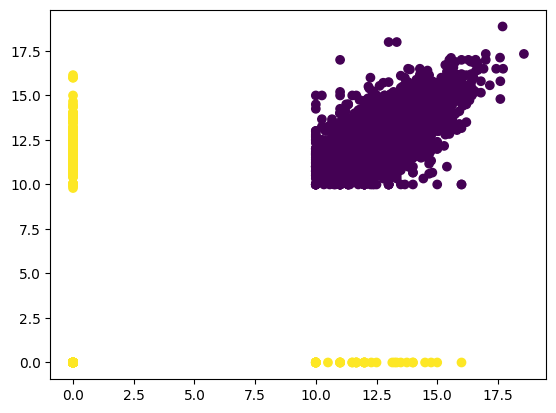

In [ ]:
plt.scatter(x=xc5.iloc[:,0],y=xc5.iloc[:,3], c=labels)

In [ ]:
from sklearn.cluster import KMeans

modelkmeans=KMeans(n_clusters=3)

In [ ]:
modelkmeans.fit(xc5)

KMeans(n_clusters=3)

In [ ]:
labels = modelkmeans.labels_

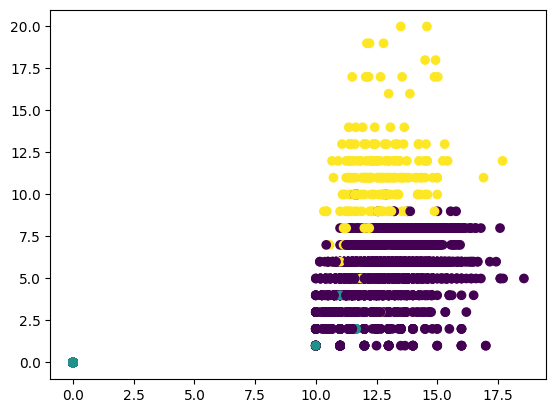

In [ ]:
plt.scatter(x=xc5.iloc[:,0],y=xc5.iloc[:,1], c=labels)

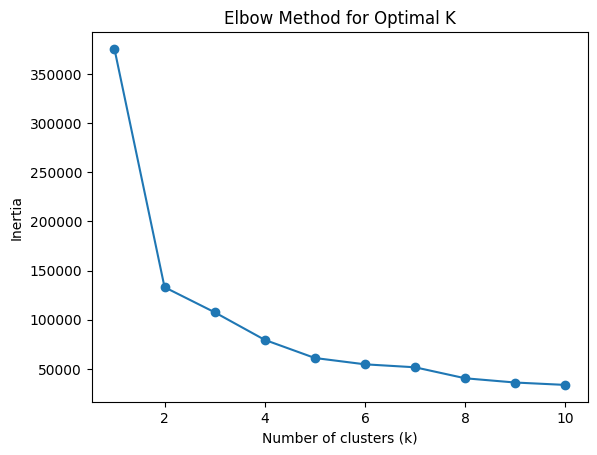

In [ ]:
K_values = range(1, 11)
inertias = []

for k in K_values:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(xc5)
    inertias.append(model.inertia_)

# PLOT ELBOW
plt.plot(K_values, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [ ]:
new_df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Attendance_Percentage,Study_Hours_Per_Week,Assignment_Submission_Rate,Login_Frequency,Video_Watch_Percentage,Doubts_Asked,Extracurricular_Score,Status,diff,New_Target,Cluster
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,78,26,46,15,93,3,49,Unsuccessful,0.000000,1,1
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,91,21,84,19,43,8,41,Successful,-0.333333,1,0
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,68,31,65,9,32,7,32,Unsuccessful,0.000000,1,1
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,54,25,55,5,65,0,26,Successful,-1.028571,1,0
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,82,23,82,5,72,7,77,Successful,0.666667,1,0


In [ ]:
from sklearn.cluster import AgglomerativeClustering

xcharc=new_df[['Marital status','Displaced','Educational special needs','Gender',
         'Tuition fees up to date','Debtor','Scholarship holder','Age at enrollment','International']]

In [ ]:
modelcharac=AgglomerativeClustering()

In [ ]:
labels=modelcharac.fit_predict(xcharc)

In [ ]:
new_df['Characteristics Group']=labels
new_df['Characteristics Group'].value_counts()

,count
Characteristics Group,
0,4056
1,368


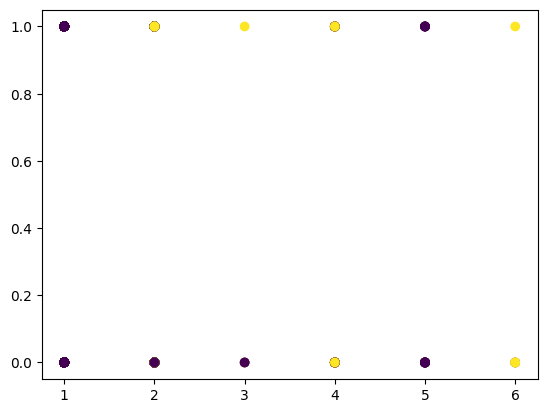

In [ ]:
plt.scatter(x=xcharc.iloc[:,0], y=xcharc.iloc[:,3], c=labels)

In [ ]:
new_df.groupby('Characteristics Group')[['Debtor','Scholarship holder','Tuition fees up to date','Gender','International']].mean()*100

,Debtor,Scholarship holder,Tuition fees up to date,Gender,International
Characteristics Group,,,,,
0,10.848126,26.208087,89.077909,34.146943,2.564103
1,17.119565,9.782609,76.902174,46.467391,1.630435


In [ ]:
pd.crosstab(
    new_df['Characteristics Group'],
    new_df['Target'],
    normalize='index'
)*100

Target,Dropout,Enrolled,Graduate
Characteristics Group,,,
0,30.325444,18.441815,51.232742
1,51.902174,12.500000,35.597826


In [ ]:
pd.crosstab(
    new_df['Characteristics Group'],
    new_df['Debtor'],
    normalize='index'
)*100

Debtor,0,1
Characteristics Group,,
0,89.151874,10.848126
1,82.880435,17.119565


In [ ]:
new_df.groupby('Characteristics Group')[['Curricular units 1st sem (credited)','Curricular units 1st sem (enrolled)',
                                         'Curricular units 1st sem (evaluations)','Curricular units 1st sem (approved)',
                                         'Curricular units 1st sem (grade)','Curricular units 1st sem (without evaluations)',
                                         'Curricular units 2nd sem (credited)','Curricular units 2nd sem (enrolled)',
                                         'Curricular units 2nd sem (evaluations)','Curricular units 2nd sem (approved)',
                                         'Curricular units 2nd sem (grade)','Curricular units 2nd sem (without evaluations)']].sum()

,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations)
Characteristics Group,,,,,,,,,,,,
0,2501,25193,33367,19140,43687.764632,540,1926,25167,32614,18177,42012.451179,589
1,640,2548,3348,1682,3387.230016,69,471,2404,3058,1447,3245.978938,76


In [ ]:
new_df.groupby('Characteristics Group')[['Curricular units 1st sem (credited)','Curricular units 1st sem (enrolled)',
                                         'Curricular units 1st sem (evaluations)','Curricular units 1st sem (approved)',
                                         'Curricular units 1st sem (grade)','Curricular units 1st sem (without evaluations)',
                                         'Curricular units 2nd sem (credited)','Curricular units 2nd sem (enrolled)',
                                         'Curricular units 2nd sem (evaluations)','Curricular units 2nd sem (approved)',
                                         'Curricular units 2nd sem (grade)','Curricular units 2nd sem (without evaluations)']].mean()

,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations)
Characteristics Group,,,,,,,,,,,,
0,0.616617,6.211292,8.226578,4.718935,10.771145,0.133136,0.474852,6.204882,8.040927,4.481509,10.358099,0.145217
1,1.739130,6.923913,9.097826,4.570652,9.204429,0.187500,1.279891,6.532609,8.309783,3.932065,8.820595,0.206522


## Module 5

Q17
Can unusual students be identified automatically?

Q18
Are there students whose academic or behavioral patterns differ significantly from the majority?

Q19
Can anomaly detection help identify students requiring special attention or investigation?

In [ ]:
new_df.head(1)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Attendance_Percentage,Study_Hours_Per_Week,Assignment_Submission_Rate,Login_Frequency,Video_Watch_Percentage,Doubts_Asked,Extracurricular_Score,Status,diff,New_Target,Cluster,Characteristics Group
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.0,0,0,0,0,0,0.0,0,10.8,1.4,1.74,Dropout,78,26,46,15,93,3,49,Unsuccessful,0.0,1,1,0


In [ ]:
from sklearn.ensemble import IsolationForest

xanom=new_df[['Displaced','Debtor','Tuition fees up to date','Curricular units 1st sem (credited)',
              'Curricular units 1st sem (grade)','Curricular units 2nd sem (grade)','Attendance_Percentage',
              'Study_Hours_Per_Week','Assignment_Submission_Rate','Login_Frequency','Video_Watch_Percentage',
              'Doubts_Asked','Extracurricular_Score']]

In [ ]:
modelf=IsolationForest()

In [ ]:
modelf.fit(xanom)

IsolationForest()

In [ ]:
labels=modelf.predict(xanom)

In [ ]:
new_df['anamolies']=labels

In [ ]:
new_df.sort_values(by='anamolies',ascending=True).head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Attendance_Percentage,Study_Hours_Per_Week,Assignment_Submission_Rate,Login_Frequency,Video_Watch_Percentage,Doubts_Asked,Extracurricular_Score,Status,diff,New_Target,Cluster,Characteristics Group,anamolies
1689,1,14,4,2,1,1,1,22,27,10,10,1,0,0,1,1,0,19,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,7.6,2.6,0.32,Dropout,51,20,79,10,27,0,31,Successful,0.000000,1,1,0,-1
1688,1,1,1,2,1,1,1,13,1,10,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Enrolled,94,29,95,3,84,3,77,Unsuccessful,0.000000,1,1,0,-1
1687,1,4,1,13,1,3,1,3,3,3,3,0,0,1,0,1,0,38,0,0,7,8,3,12.666667,0,0,5,5,0,0.000000,0,13.9,-0.3,0.79,Dropout,62,27,86,16,24,3,63,Unsuccessful,-12.666667,1,1,1,-1
1686,1,8,3,6,1,1,1,23,1,10,10,1,0,0,1,1,0,21,0,0,5,11,0,0.000000,0,0,5,10,5,12.285714,1,10.8,1.4,1.74,Graduate,42,21,39,17,84,14,96,Unsuccessful,12.285714,1,1,0,-1
1682,1,1,2,14,1,1,1,13,1,10,5,1,0,1,1,1,0,20,0,0,5,5,4,12.000000,0,0,5,6,5,11.600000,0,9.4,-0.8,-3.12,Dropout,59,3,81,3,25,8,60,Successful,-0.400000,1,0,0,-1


In [ ]:
new_df['anamolies'].value_counts()

,count
anamolies,
1,2747
-1,1677


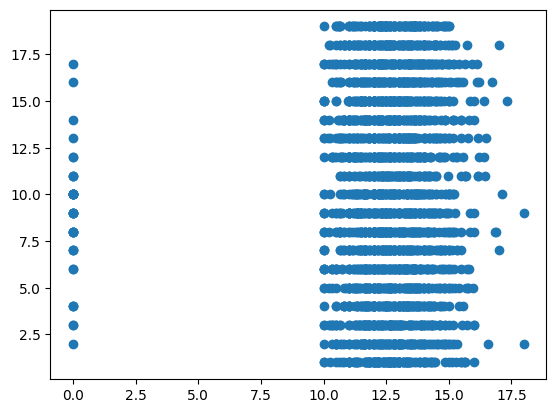

In [ ]:
plt.scatter(xanom.iloc[labels==1,4],xanom.iloc[labels==1,9])

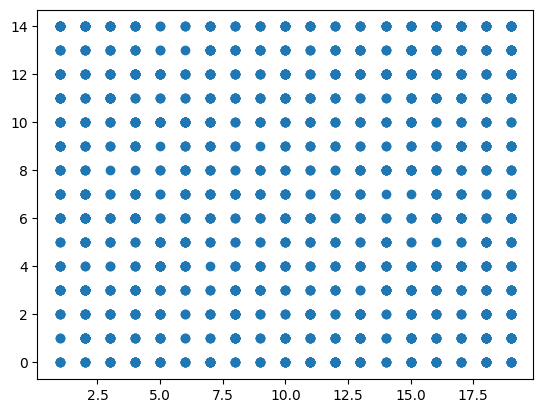

In [ ]:
plt.scatter(xanom.iloc[labels==-1,9],xanom.iloc[labels==-1,11])

In [ ]:
pd.crosstab(
    new_df['anamolies'],
    new_df['Target'],
    normalize='index'
)*100

Target,Dropout,Enrolled,Graduate
anamolies,,,
-1,61.359571,12.880143,25.760286
1,14.270113,21.041136,64.688751


## Module 6

Q20
Which factors contribute most to student dropout?

Q21
Which variables have the strongest influence on academic success?

Q22
Can the institution identify key areas requiring intervention?

In [ ]:
new_df.head(1)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Attendance_Percentage,Study_Hours_Per_Week,Assignment_Submission_Rate,Login_Frequency,Video_Watch_Percentage,Doubts_Asked,Extracurricular_Score,Status,diff,New_Target,Cluster,Characteristics Group,anamolies
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.0,0,0,0,0,0,0.0,0,10.8,1.4,1.74,Dropout,78,26,46,15,93,3,49,Unsuccessful,0.0,1,1,0,-1


In [ ]:
from sklearn.ensemble import RandomForestClassifier

xxx = new_df[['Marital status','Application mode','Application order','Course','Displaced','Educational special needs',
              'Debtor','Tuition fees up to date','Gender','Scholarship holder','Age at enrollment','International',
              'Curricular units 1st sem (credited)','Curricular units 1st sem (enrolled)',
              'Curricular units 1st sem (evaluations)','Curricular units 1st sem (approved)',
              'Curricular units 1st sem (grade)','Curricular units 1st sem (without evaluations)',
              'Curricular units 2nd sem (credited)','Curricular units 2nd sem (enrolled)',
              'Curricular units 2nd sem (evaluations)','Curricular units 2nd sem (approved)','Curricular units 2nd sem (grade)',
              'Curricular units 2nd sem (without evaluations)','Unemployment rate','Inflation rate','Attendance_Percentage',
              'Study_Hours_Per_Week','Assignment_Submission_Rate','Login_Frequency','Video_Watch_Percentage',
              'Doubts_Asked','Extracurricular_Score']]

yyy = new_df['Target']

In [ ]:
MODEL = RandomForestClassifier(random_state=42)

In [ ]:
xxx_train, xxx_test, yyy_train, yyy_test = train_test_split(xxx,yyy,test_size=0.3)

In [ ]:
MODEL.fit(xxx_train, yyy_train)

RandomForestClassifier(random_state=42)

In [ ]:
importance = pd.DataFrame({
    'Feature': xxx.columns,
    'Importance': MODEL.feature_importances_
})*100

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
21,Curricular units 2nd sem (approved)Curricular ...,13.303007
22,Curricular units 2nd sem (grade)Curricular uni...,9.458473
15,Curricular units 1st sem (approved)Curricular ...,9.402616
16,Curricular units 1st sem (grade)Curricular uni...,6.416078
7,Tuition fees up to dateTuition fees up to date...,4.157297
20,Curricular units 2nd sem (evaluations)Curricul...,3.877868
30,Video_Watch_PercentageVideo_Watch_PercentageVi...,3.858753
28,Assignment_Submission_RateAssignment_Submissio...,3.626462
26,Attendance_PercentageAttendance_PercentageAtte...,3.580724
32,Extracurricular_ScoreExtracurricular_ScoreExtr...,3.552335


In [ ]:
new_df.groupby('Target')[['Marital status','Application mode','Application order','Course','Displaced','Educational special needs',
              'Debtor','Tuition fees up to date','Gender','Scholarship holder','Age at enrollment','International',
              'Curricular units 1st sem (credited)','Curricular units 1st sem (enrolled)',
              'Curricular units 1st sem (evaluations)','Curricular units 1st sem (approved)',
              'Curricular units 1st sem (grade)','Curricular units 1st sem (without evaluations)',
              'Curricular units 2nd sem (credited)','Curricular units 2nd sem (enrolled)',
              'Curricular units 2nd sem (evaluations)','Curricular units 2nd sem (approved)','Curricular units 2nd sem (grade)',
              'Curricular units 2nd sem (without evaluations)','Unemployment rate','Inflation rate','Attendance_Percentage',
              'Study_Hours_Per_Week','Assignment_Submission_Rate','Login_Frequency','Video_Watch_Percentage',
              'Doubts_Asked','Extracurricular_Score']].mean()

,Marital status,Application mode,Application order,Course,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,Attendance_Percentage,Study_Hours_Per_Week,Assignment_Submission_Rate,Login_Frequency,Video_Watch_Percentage,Doubts_Asked,Extracurricular_Score
Target,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Dropout,1.261084,8.342013,1.593244,9.898663,0.470795,0.011963,0.219564,0.678395,0.493315,0.094300,26.068966,0.022519,0.609430,5.821253,7.751583,2.551724,7.256656,0.192118,0.449683,5.780436,7.173821,1.940183,5.899339,0.237861,11.616397,1.283955,69.035186,17.667136,64.448276,10.370866,58.123856,7.057002,49.228008
Enrolled,1.152393,7.238035,1.625945,9.732997,0.545340,0.013854,0.113350,0.947103,0.386650,0.163728,22.369018,0.030227,0.507557,5.964736,9.341310,4.318640,11.125257,0.177582,0.358942,5.938287,9.435768,4.057935,11.117364,0.187657,11.272544,1.211713,70.448363,17.382872,64.306045,10.295970,59.269521,6.998741,49.355164
Graduate,1.134903,5.824808,1.851064,9.959258,0.599366,0.010412,0.045722,0.986872,0.248076,0.377999,21.783612,0.024445,0.847442,6.669534,8.276596,6.232232,12.643655,0.088275,0.666818,6.628339,8.142146,6.177003,12.697276,0.080579,11.639339,1.197918,69.765052,17.655048,64.851969,10.027614,60.521956,7.032141,49.944319


## Module 7

Q23
If intervention resources are limited, which students should be prioritized?

Q24
What actions can educational institutions take to reduce dropout rates?

Q25
Which courses require immediate attention due to higher dropout rates?

Q26
Which student categories would benefit most from support programs?

In [ ]:
pd.crosstab(
    new_df['Course'],
    new_df['Target'],
    normalize='index'
)*100

Target,Dropout,Enrolled,Graduate
Course,,,
1,66.666667,25.000000,8.333333
2,38.139535,17.209302,44.651163
3,33.023256,9.767442,57.209302
4,40.952381,17.619048,41.428571
5,22.566372,18.584071,58.849558
6,26.706231,22.255193,51.038576
7,54.117647,37.647059,8.235294
8,55.319149,14.893617,29.787234
9,35.263158,28.421053,36.315789


# Notes

1) in xgboost target variable should also be numeric

2) y_prob=model.predict_proba(x)

3) if we want to print entire as a new table use dataframe

4) to identify which factors has how much impact on target variable use:
importance = model1.feature_importances_ (random forest)

5) .groupby

6) .crosstab

7) if we want to plot with dataframe write .iloc or if array direct do like x[:,0]